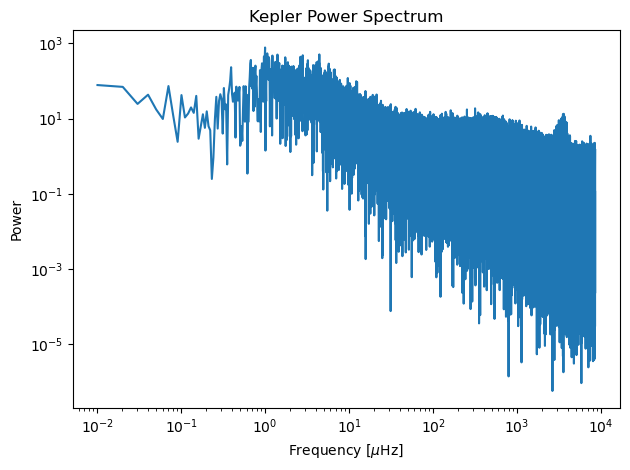

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Path to the .pow file
pow_file = r"C:\Users\mason\OneDrive - University of Birmingham\Asteroseismology\GroupStudies202021_KeplerSpectra_Batch1\GroupStudies202021_KeplerSpectra\kplr008006161_kasoc-ts_slc_v1.pow"

# Load the data
# Assumes: column 0 = frequency (µHz), column 1 = power
data = np.loadtxt(pow_file)

frequency = data[:, 0]
power = data[:, 1]

# Plot
plt.figure()
plt.plot(frequency, power)
plt.xlabel("Frequency [$\mu$Hz]")
plt.ylabel("Power")
plt.title("Kepler Power Spectrum")
plt.yscale("log")  # standard for asteroseismic power spectra
plt.xscale("log")
plt.tight_layout()
plt.show()


In [11]:
fmin = 2500.0  # µHz
fmax = 5000.0  # µHz

mask = (frequency >= fmin) & (frequency <= fmax)

freq_sel = frequency[mask]
power_sel = power[mask]

print(freq_sel.min(), freq_sel.max())
print(len(freq_sel))


2500.0031309120277 4999.99617575721
247867


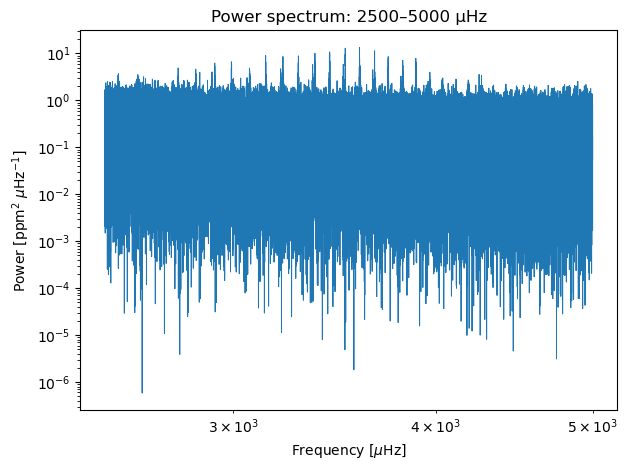

In [12]:
plt.figure()
plt.plot(freq_sel, power_sel, lw=0.7)
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"Frequency [$\mu$Hz]")
plt.ylabel(r"Power [ppm$^2$ $\mu$Hz$^{-1}$]")
plt.title("Power spectrum: 2500–5000 µHz")
plt.tight_layout()
plt.show()


In [13]:
df = np.diff(freq_sel)

print("Median Δν bin:", np.median(df))
print("Std of Δν bin:", np.std(df))


Median Δν bin: 0.010086066845815367
Std of Δν bin: 3.0909748110763474e-13


In [14]:
print("Min power:", np.min(power_sel))
print("Any NaNs?", np.any(np.isnan(power_sel)))
print("Any infs?", np.any(np.isinf(power_sel)))


Min power: 5.829992566305415e-07
Any NaNs? False
Any infs? False


In [15]:
df = np.median(np.diff(freq_sel))  # µHz
print("Δf =", df, "µHz")


Δf = 0.010086066845815367 µHz


In [69]:
smooth_width_muHz = 600.0
smooth_width_bins = int(smooth_width_muHz / df)

print("Smoothing width (bins):", smooth_width_bins)


Smoothing width (bins): 59488


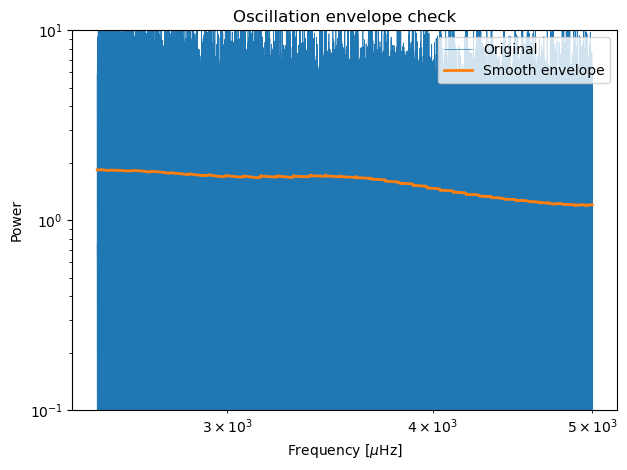

In [70]:
from scipy.ndimage import uniform_filter1d

background = uniform_filter1d(power_sel, size=smooth_width_bins)

plt.figure()
plt.plot(freq_sel, power_sel, lw=0.5, label="Original")
plt.plot(freq_sel, background, lw=2, label="Smooth envelope")
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"Frequency [$\mu$Hz]")
plt.ylabel("Power")
plt.ylim(0.1,10)
plt.legend()
plt.title("Oscillation envelope check")
plt.tight_layout()
plt.show()


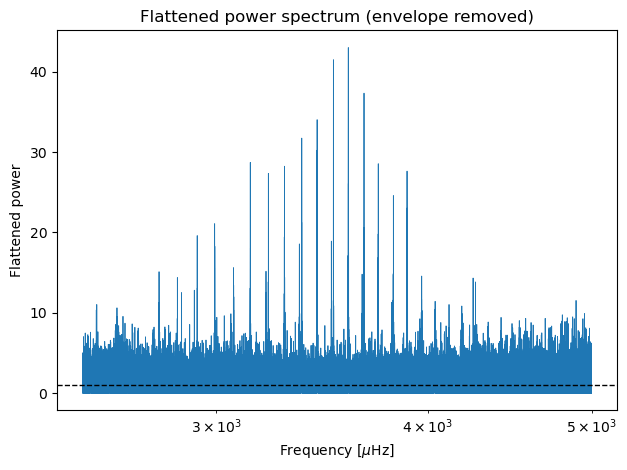

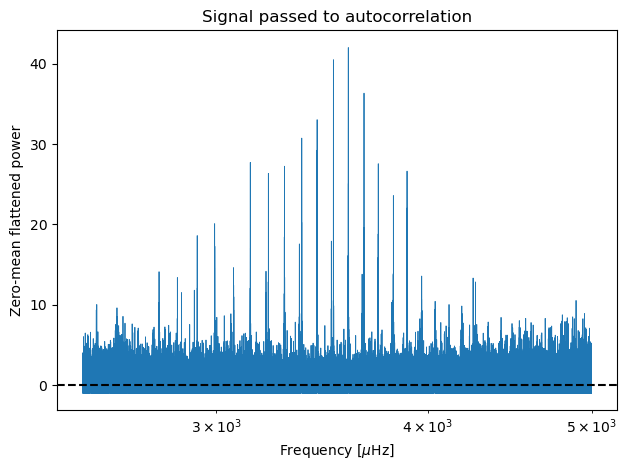

-9.815337770831063e-17 1.173422613881146


In [75]:
power_flat = power_sel / background
#power_flat /= np.median(power_flat)
plt.figure()
plt.plot(freq_sel, power_flat, lw=0.6)
plt.axhline(1.0, color="k", ls="--", lw=1)
plt.xscale("log")
plt.xlabel(r"Frequency [$\mu$Hz]")
plt.ylabel("Flattened power")
plt.title("Flattened power spectrum (envelope removed)")
plt.tight_layout()
plt.show()

signal = power_flat - np.mean(power_flat)
plt.figure()
plt.plot(freq_sel, signal, lw=0.6)
plt.axhline(0.0, color="k", ls="--")
plt.xscale("log")
plt.xlabel(r"Frequency [$\mu$Hz]")
plt.ylabel("Zero-mean flattened power")
plt.title("Signal passed to autocorrelation")
plt.tight_layout()
plt.show()
print(np.mean(signal), np.std(signal))


In [76]:
acf_full = np.correlate(signal, signal, mode="full")



In [77]:
N = len(signal)
acf = acf_full[N-1:]


In [78]:
lags_bins = np.arange(len(acf))
lags_muHz = lags_bins * df


In [79]:
acf /= acf[0]


In [80]:
lag_min = 20.0
lag_max = 200.0

mask_lag = (lags_muHz >= lag_min) & (lags_muHz <= lag_max)

lags_plot = lags_muHz[mask_lag]
acf_plot = acf[mask_lag]


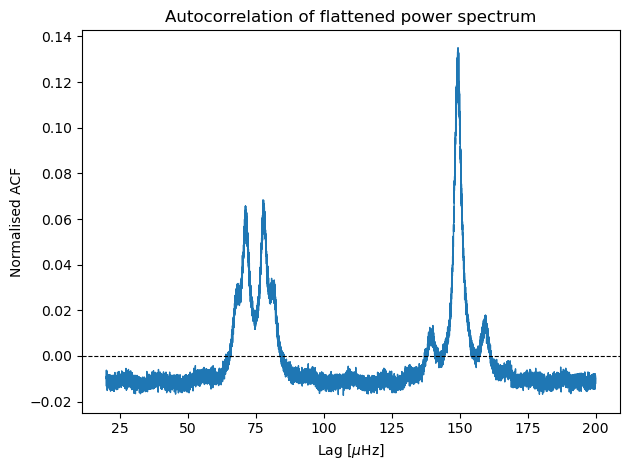

In [81]:
plt.figure()
plt.plot(lags_plot, acf_plot, lw=1)
plt.axhline(0.0, color="k", ls="--", lw=0.8)
plt.xlabel(r"Lag [$\mu$Hz]")
plt.ylabel("Normalised ACF")
plt.title("Autocorrelation of flattened power spectrum")
plt.tight_layout()
plt.show()
